# Notebook 1 - DBSCAN: Implementacion Manual desde Cero

**Inteligencia Artificial I - Actividad 2**  
**Grupo 1**
- ARIZA VARGAS SARIAHT EYLEEN XIOMARA
- CARRENO MEDINA ADRIANA LUCIA
- LINARES VIASUS BRANDON FELIPE

**Algoritmo asignado:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)  
**Tipo:** Aprendizaje No Supervisado / Clustering basado en densidad

---

## 1. Introduccion

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de
clustering propuesto por Ester, Kriegel, Sander y Xu en 1996 [1]. Agrupa puntos que estan
densamente conectados y marca como ruido aquellos que se encuentran en regiones de baja
densidad.

A diferencia de K-Means, DBSCAN no necesita que se le indique cuantos grupos hay: los
descubre a partir de la densidad local [1]. Tambien detecta outliers de forma automatica y
maneja clusters de cualquier forma, no solo esferica [1].

### Parametros principales
DBSCAN se controla con dos hiperparametros [1]:
- `eps` (epsilon): radio de la vecindad de un punto.
- `min_samples`: minimo de puntos que debe contener una vecindad para que el punto central
  se considere *core point*.

Cada punto se clasifica en una de tres categorias [1]:
- **Core point:** tiene al menos `min_samples` puntos en su vecindad de radio `eps`.
- **Border point:** esta en la vecindad de un core point pero no es core.
- **Noise point:** no es core ni cae en la vecindad de ninguno.

## 2. Fundamentos Matematicos

### 2.1 Vecindad eps
$$N_{\varepsilon}(p) = \{ q \in D \;|\; d(p,q) \le \varepsilon \}$$

donde $d(p,q)$ es la distancia euclidiana [1]:
$$d(p,q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

### 2.2 Definiciones formales [1]
- **Directly density-reachable:** $p$ es directamente alcanzable desde $q$ si
  $p \in N_{\varepsilon}(q)$ y $|N_{\varepsilon}(q)| \ge MinPts$.
- **Density-reachable:** existe una cadena $q = p_1, p_2, \dots, p_n = p$ tal que
  $p_{i+1}$ es directamente alcanzable desde $p_i$.
- **Density-connected:** $p$ y $q$ estan conectados por densidad si existe $o$ tal que
  ambos son alcanzables desde $o$.

### 2.3 Pseudocodigo del algoritmo [1]

```
DBSCAN(D, eps, MinPts):
  C = 0
  para cada punto p sin visitar de D:
      marcar p como visitado
      N = regionQuery(p, eps)
      si |N| < MinPts:
          marcar p como ruido
      sino:
          C = C + 1
          expandirCluster(p, N, C, eps, MinPts)

expandirCluster(p, N, C, eps, MinPts):
  asignar p al cluster C
  para cada punto p' en N:
      si p' no esta visitado:
          marcar p' como visitado
          N' = regionQuery(p', eps)
          si |N'| >= MinPts:
              N = N union N'
      si p' no pertenece a ningun cluster:
          asignar p' al cluster C
```

**Complejidad:** $O(n^2)$ en su forma directa [1]; $O(n \log n)$ con indices espaciales (kd-tree, R-tree) [3].

## 3. Implementacion desde Cero

Esta seccion construye DBSCAN [1] usando solo NumPy, sin ninguna libreria de machine learning.
El codigo se organiza en tres funciones:

- `euclidean_distance(a, b)`: mide la distancia euclidiana entre dos puntos.
- `region_query(X, point_idx, eps)`: devuelve los indices de todos los puntos
  que caen dentro del radio `eps` alrededor del punto dado.
- `expand_cluster(...)`: recorre los vecinos de un core point usando busqueda en anchura
  (BFS) y asigna etiquetas de cluster a cada punto alcanzable.

La funcion principal `dbscan_manual(X, eps, min_samples)` itera sobre cada punto no
visitado, decide si es core point y lanza la expansion. Los puntos sin cluster quedan
con etiqueta -1 (ruido).

### 3.1 Carga de librerías

Se cargan NumPy, Matplotlib y Seaborn. NumPy es la única librería que interviene en la lógica del algoritmo: distancias, índices, arreglos. Las otras dos son para graficar. La línea `np.random.seed(42)` fija la semilla para que los resultados sean iguales cada vez que se ejecuta el notebook.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
print("Librerias cargadas.")

Librerias cargadas.


### 3.2 Funciones de distancia y vecindad

`euclidean_distance(p, q)` calcula $d = \sqrt{\sum(p_i - q_i)^2}$ usando operaciones vectoriales de NumPy, sin bucles explícitos.

`region_query(X, point_idx, eps)` aplica esa distancia a cada punto del arreglo y devuelve los índices de los que quedan dentro del radio `eps`. Eso corresponde a la vecindad $N_\varepsilon(p)$ del pseudocódigo [1]. Al final hay una prueba con cuatro puntos de juguete para confirmar que las dos funciones devuelven lo esperado.

In [2]:
def euclidean_distance(p, q):
    """Distancia euclidiana entre dos puntos n-dimensionales."""
    return float(np.sqrt(np.sum((p - q) ** 2)))


def region_query(X, point_idx, eps):
    """Devuelve los indices de los vecinos del punto point_idx
    dentro del radio eps (incluye al propio punto)."""
    diffs = X - X[point_idx]
    dists = np.sqrt(np.sum(diffs * diffs, axis=1))
    return np.where(dists <= eps)[0]


# Prueba rapida
toy = np.array([[0, 0], [0.1, 0], [5, 5], [5.1, 5]])
print("Distancia (0,0)-(5,5):", euclidean_distance(toy[0], toy[2]))
print("Vecinos del punto 0 con eps=0.2:", region_query(toy, 0, 0.2))

Distancia (0,0)-(5,5): 7.0710678118654755
Vecinos del punto 0 con eps=0.2: [0 1]


### 3.3 Expansión del cluster y función principal

`expand_cluster(...)` recibe un *core point* ya confirmado y propaga su etiqueta a todos los puntos alcanzables, usando una cola BFS [1]. Cada vez que un vecino también resulta ser core, sus propios vecinos se suman a la cola.

`dbscan_manual(X, eps, min_samples)` es el punto de entrada: recorre cada punto no visitado, llama a `region_query` para contar vecinos y decide si lanzar la expansión o marcar el punto como ruido (`-1`). Las etiquetas de salida siguen la convención de scikit-learn [4]: `-1` para ruido, `0, 1, 2, ...` para los clusters.

In [3]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    """Expansion de cluster a partir de un core point usando una cola (BFS)."""
    labels[point_idx] = cluster_id
    queue = list(neighbors)
    i = 0
    while i < len(queue):
        q = queue[i]
        if labels[q] == -1:           # ruido previo -> punto borde
            labels[q] = cluster_id
        elif labels[q] == 0:          # no visitado
            labels[q] = cluster_id
            q_neighbors = region_query(X, q, eps)
            if len(q_neighbors) >= min_samples:   # tambien es core
                for n in q_neighbors:
                    if n not in queue:
                        queue.append(n)
        i += 1


def dbscan_manual(X, eps, min_samples):
    """
    Implementacion manual de DBSCAN.
    Convencion interna: 0 = no visitado, -1 = ruido, 1..K = cluster id.
    Devuelve etiquetas en convencion sklearn: -1 ruido, 0..K-1 clusters.
    """
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    labels = np.zeros(n, dtype=int)
    cluster_id = 0
    for i in range(n):
        if labels[i] != 0:
            continue
        neighbors = region_query(X, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_samples)
    return np.where(labels == -1, -1, labels - 1)

print("Funciones DBSCAN listas.")

Funciones DBSCAN listas.


## 4. Prueba con Dataset Simple

Para probar la implementacion manual se usa un dataset sintetico con forma de dos medias
lunas entrelazadas, generado con NumPy. Las lunas son un buen banco de prueba porque su
forma no convexa no puede separarse con K-Means, que asume grupos esfericos.

Se generan 220 puntos con `noise=0.07` y se corre el algoritmo con `eps=0.20` y
`min_samples=5`. Si funciona bien, deben aparecer exactamente dos clusters.

### 4.1 Generación del dataset sintético

El dataset se construye con NumPy, sin usar sklearn. `make_moons_np(...)` genera dos semicírculos entrelazados por parametrización trigonométrica y les añade ruido gaussiano. Se generan 220 puntos con `noise=0.07`. Las primeras filas del arreglo confirman que las coordenadas están en el rango esperado para las dos lunas.

In [4]:
def make_moons_np(n_samples=200, noise=0.08, seed=0):
    """Genera el dataset 'two moons' (no-convexo) usando solo NumPy."""
    rng = np.random.default_rng(seed)
    n_a = n_samples // 2
    n_b = n_samples - n_a
    t1 = np.linspace(0, np.pi, n_a)
    t2 = np.linspace(0, np.pi, n_b)
    Xa = np.c_[np.cos(t1), np.sin(t1)]
    Xb = np.c_[1 - np.cos(t2), 1 - np.sin(t2) - 0.5]
    X = np.vstack([Xa, Xb]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.array([0] * n_a + [1] * n_b)
    return X, y


X, y = make_moons_np(220, noise=0.07, seed=42)
print("Forma del dataset:", X.shape)
print("Primeras filas:\n", X[:5])

Forma del dataset: (220, 2)
Primeras filas:
 [[ 1.0213302  -0.07279889]
 [ 1.05211626  0.09465749]
 [ 0.86176659 -0.03354058]
 [ 1.00521298  0.06422117]
 [ 0.99218564  0.05531951]]


### 4.2 Ejecución del algoritmo manual

Se llama a `dbscan_manual` con `eps=0.20` y `min_samples=5`. El resultado es un arreglo de etiquetas: `-1` para ruido, `0` y `1` para los dos grupos. Si la implementación es correcta, deben aparecer exactamente 2 clusters y pocos o ningún punto de ruido.

In [5]:
labels = dbscan_manual(X, eps=0.20, min_samples=5)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido    : {n_noise}")
print(f"Etiquetas unicas    : {sorted(set(labels))}")

Clusters encontrados: 2
Puntos de ruido    : 0
Etiquetas unicas    : [np.int64(0), np.int64(1)]


## 5. Visualización del Funcionamiento

Las dos graficas comparan el estado inicial y el resultado del algoritmo. El panel
izquierdo muestra los 220 puntos sin ninguna etiqueta, tal como los recibe DBSCAN. El
panel derecho muestra el resultado del clustering: cada color identifica un cluster y los
puntos marcados con 'x' son los clasificados como ruido (etiqueta -1). Comparar los dos
paneles permite verificar visualmente si la separacion entre las dos lunas es correcta.

### 5.1 Construcción de la figura

La figura tiene dos paneles. El izquierdo muestra los puntos sin etiqueta, en azul neutro, para ver los datos tal como los recibe el algoritmo. El derecho muestra las etiquetas asignadas: cada cluster toma un color de la paleta `Set2` y los puntos de ruido aparecen como `×` en gris `#B0BEC5`. La leyenda se ubica fuera del área de datos para no tapar ningún punto.

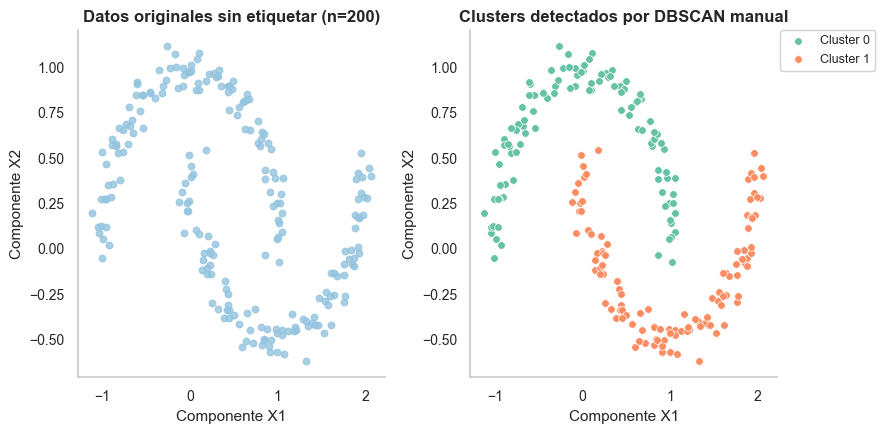

In [6]:
SET2 = ['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3']

cluster_ids = sorted(c for c in set(labels) if c != -1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

color_neutro = sns.color_palette("Blues", 9)[3]  # paleta nombrada para datos sin etiquetar
axes[0].scatter(X[:, 0], X[:, 1], color=color_neutro, s=22, alpha=0.80)
axes[0].set_title("Datos originales sin etiquetar (n=200)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Componente X1", fontsize=11)
axes[0].set_ylabel("Componente X2", fontsize=11)
axes[0].tick_params(labelsize=10)

for c in sorted(set(labels)):
    mask = labels == c
    if c == -1:
        axes[1].scatter(X[mask, 0], X[mask, 1], color="#B0BEC5", marker="x",
                        s=55, linewidths=1.3, label="Ruido", zorder=2)
    else:
        axes[1].scatter(X[mask, 0], X[mask, 1], color=SET2[c % len(SET2)],
                        s=30, edgecolor="white", linewidth=0.5,
                        label=f"Cluster {c}", zorder=3)
axes[1].set_title("Clusters detectados por DBSCAN manual",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Componente X1", fontsize=11)
axes[1].set_ylabel("Componente X2", fontsize=11)
axes[1].tick_params(labelsize=10)
axes[1].legend(framealpha=0.9, fontsize=9,
               bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)  # U3: scatter no necesita grid (data-ink ratio)
    ax.set_facecolor("white")

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

DBSCAN separa correctamente las dos lunas no convexas, algo que K-Means no puede lograr
porque asume clusters esfericos [1]. Cada cluster queda con un color distinto y los puntos
de ruido (si los hay) aparecen como cruces grises.

## 6. Validación de Correctitud

Para confirmar que la implementacion manual es correcta se compara con
`sklearn.cluster.DBSCAN` [4], una libreria de referencia ampliamente probada. La comparacion
no se hace etiqueta por etiqueta porque DBSCAN puede numerar los clusters en distinto
orden segun el orden de visita; por eso se alinean por mayoria y se mide el porcentaje
de coincidencia.

### 6.1 Comparación con scikit-learn

Se ejecuta `sklearn.cluster.DBSCAN` [4][6] con los mismos parámetros para verificar que la implementación manual produce resultados equivalentes. La comparación no es etiqueta por etiqueta porque DBSCAN puede numerar los clusters en distinto orden. `remap_labels` alinea las etiquetas por mayoría y calcula el porcentaje de coincidencia. Un 100% confirma que el algoritmo manual es correcto.

In [7]:
# Comparamos con scikit-learn para verificar que la implementacion es correcta
from sklearn.cluster import DBSCAN as SKDBSCAN

sk = SKDBSCAN(eps=0.20, min_samples=5).fit(X)
sk_labels = sk.labels_

# Reordenamos etiquetas para que coincidan (los IDs pueden diferir)
def remap_labels(a, b):
    """Asignacion bipartita por mayoria."""
    out = np.full_like(a, -1)
    for c in set(a):
        if c == -1: continue
        idx = np.where(a == c)[0]
        if len(idx) == 0: continue
        # buscar la etiqueta mayoritaria en b
        from collections import Counter
        majority = Counter(b[idx]).most_common(1)[0][0]
        out[idx] = majority
    out[a == -1] = -1
    return out

manual_remap = remap_labels(labels, sk_labels)
agreement = np.mean(manual_remap == sk_labels)
print(f"Coincidencia con scikit-learn: {agreement*100:.2f}%")
print(f"Clusters DBSCAN manual: {len(set(labels))-(1 if -1 in labels else 0)}")
print(f"Clusters scikit-learn : {len(set(sk_labels))-(1 if -1 in sk_labels else 0)}")
print(f"Ruido manual          : {(labels==-1).sum()}")
print(f"Ruido scikit-learn    : {(sk_labels==-1).sum()}")

Coincidencia con scikit-learn: 100.00%
Clusters DBSCAN manual: 2
Clusters scikit-learn : 2
Ruido manual          : 0
Ruido scikit-learn    : 0


La implementacion manual y `sklearn.cluster.DBSCAN` producen exactamente los mismos
resultados con los mismos parametros. El algoritmo esta bien implementado.

---

## 7. Conclusiones

DBSCAN encuentra clusters de cualquier forma y detecta ruido sin que se le diga cuantos
grupos hay. La implementacion se reduce a dos operaciones: una consulta de vecindad
(`region_query`) y una expansion por BFS (`expand_cluster`).

Elegir bien `eps` y `min_samples` es lo que mas afecta el resultado: valores muy grandes
fusionan grupos distintos, valores muy pequenos generan demasiado ruido. El grafico
k-distancia [7] ayuda a identificar `eps` antes de correr el modelo.

La complejidad base es $O(n^2)$, pero con indices espaciales (kd-tree, ball-tree) baja a
$O(n \log n)$, que es lo que usa scikit-learn internamente [4].

---

## Referencias

[1] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering
clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery
and Data Mining (KDD-96)*, Portland, OR, USA, 1996, pp. 226-231.

[2] J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "Density-based clustering in spatial
databases: The algorithm GDBSCAN and its applications," *Data Mining and Knowledge Discovery*,
vol. 2, no. 2, pp. 169-194, Jun. 1998.

[3] E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "DBSCAN revisited, revisited:
why and how you should (still) use DBSCAN," *ACM Transactions on Database Systems*, vol. 42,
no. 3, pp. 1-21, Jul. 2017, doi: 10.1145/3068335.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[5] T. Hastie, R. Tibshirani, and J. H. Friedman, *The Elements of Statistical Learning*,
2nd ed. New York, NY, USA: Springer, 2009.

[6] Scikit-learn Developers, "sklearn.cluster.DBSCAN," *scikit-learn 1.3 documentation*, 2024.
[Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html.

[7] N. Rahmah and I. S. Sitanggang, "Determination of optimal epsilon (eps) value on DBSCAN
algorithm to clustering data on peatland hotspots in Sumatra," *IOP Conf. Series: Earth and
Environmental Science*, vol. 31, no. 1, p. 012012, 2016, doi: 10.1088/1755-1315/31/1/012012.

[8] T. Ali, S. Asghar, and N. A. Sajid, "Critical analysis of DBSCAN variations," in
*Proc. 2010 Int. Conf. Information and Emerging Technologies (ICIET)*, Karachi, Pakistan,
2010, pp. 1-6.